<a href="https://colab.research.google.com/github/stanford-cme-307/demos/blob/main/Mullticast_Routing_Demonstration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Demonstration of Formulating and Solving The Multicast Routing Problem

### Created by Yingxi

Nowadays, rapid and data-driven decision-making is the cornerstone of many practically applications. This notebook introduces an optimization problem inspired by real-world applications, and provides a case study for how difference formulations of the same problem can yield very different runtime performances.

In [ ]:
import numpy as np
import cvxpy as cp
import networkx as nx
import matplotlib.pyplot as plt
import gurobipy as gp

import random
import time

## 1. Problem Definition

A fleet of $n$ ships seeks to communicate and coordinate activity
by establishing a set of persistent communication links.
Each ship $v \in V = \{1,\ldots,n\}$ can communicate with ships nearby.
We will record the set of possible communication links as a directed
graph $G = (V, E)$.

A set of messages $m \in 1,\ldots,M$ are to be sent over the network,
each starting at a source ship $s_m \in S \subseteq V$
and requiring bandwidth $a_m \in \mathbb{R}$.
Each source ship $s_m$ has a list of target ships $T_m \subseteq V$ which are to
receive the message.
If there were but a single message to send in the entire network,
the problem of finding a set of links to establish would be a classic Steiner Tree problem.
Instead, the difficulty of the problem comes from the fact that the ships must send multiple messages
over the same network, and the maximum delay on one route from a root to a terminal
cannot exceed a threshold $D$.

But the communication bandwidth is limited:
each link $e \in E$ has a characteristic bandwidth $b_e$ and delay $d_e$.
Each node $v \in V$ can only send messages to its neighbors
$W = \{w | (v, w) \in E\}$,
through its outgoing edges
$\delta^+(v) = \{(v, w) \in E\} \subset E$
and can only receive messages from its neighbors
$U = \{u | (u, v) \in E\}$ through its incoming edges
$\delta^-(v) = \{(u, v) \in E\} \subset E$.

Here is an example problem:



<p align="center">
    <img src="https://drive.google.com/uc?export=view&id=1y_9IMc1dpRKR6Gdw9Iu8iMxxvt_mYm6Y" width="800" />
</p>

In this example multicast routing problem, we have two messages to be sent. $M = \{\text{orange}, \text{blue}\}$. Let $a_{\text{orange}} = 2$, $a_{\text{blue}} = 3$. Bandwidth is labeled on each edge, delay omitted.

Below is an example of feasible communication links:

<p align="center">
    <img src="https://drive.google.com/uc?export=view&id=1Hy8PRP58p373bKoQYavHQQbEK9XxwWFa" width="775" />
</p>

Note that on edge $(3, 4)$, two messages are able to share the link because the link has a bandwidth $5 \geq 2 + 3$.

## 2. Mixed-Integer Programming (MIP) Formulation

### 2.1 The Cut Formulation

A natural way to formulate this problem is to define $x_e, m$
for each edge $e \in E$ and message $m \in 1,...,M$ to indicate
whether edge $e$ is taken by message $e$ ($x_e, m = 1$)
or not ($x_e, m = 0$).
Inspired by the set-coverage approach used by Aneja
in \cite{aneja80} to formulate the Steiner Tree problem,
we develop an LP formulation of the multicast routing problem.
For every $W \subset V$,
if the subset $W$ contains at least one terminal
$t \in T_m$ and does not contain the source ship $s_m$,
then at least one edge $e \in \delta^{-1}(W)$
is chosen by message m.


\begin{align}
    \textrm{maximize} \quad & \sum_{e \in E} p_e \\
    \textrm{subject to} \quad
      & \sum_{e \in \delta^{-1}(W)} x_{e, m} \geq 1 & &\forall{m} \in [M], W \subset V_m, r_m \notin W, W \cap T \neq \emptyset  \\
      & \sum_{i=1}^{m} x_{e,m} s_m + p_e =  b_e \quad & &\forall{e} \in E \\
      & x_{e,m} \in\{0,1\} \quad & &\forall{e} \in E, m \in [M]  \\
\end{align}


### Instance Generator and Helper Functions for Cut Formuulation
Make sure to run the following folded section:

In [ ]:
def gen_problem(num_nodes, num_msg):
    """
    Generate a connected problem instance given number of nodes and number
    of messages.
    """

    G = nx.random_regular_graph(3, num_nodes)
    G = G.to_directed()

    bandwidth = {}

    delay = {}

    for e in G.edges():
        bandwidth[e] = np.random.randint(250, 601)  # 250-600
        delay[e] = np.random.randint(1, 3)

    nx.set_edge_attributes(G, bandwidth, "bandwidth")
    nx.set_edge_attributes(G, delay, "delay")

    msg_info = {}
    for i in range(num_msg):

        msg_size = np.random.randint(16, 65)  # 16-64
        node_selected = np.random.choice(num_nodes, size=4, replace=False)

        msg_info[i] = {'sources': [node_selected[0]],
                       'destinations': node_selected[1:4],
                       'size': msg_size}

    return G, msg_info

In [ ]:
# Helper functions for the cut formulation
def all_directed_cut_set(G, T, r):
    """
    Return all cut set W such that 0 < |W n T| and [r not in W]
    """
    N = nx.number_of_nodes(G)
    allSubset = [[]]
    W = [[]]
    r = r[0]

    for n in range(N):
        length = len(allSubset)
        for i in range(length):
            subset = allSubset[i]+[n]
            allSubset.append(subset)

    for S in allSubset:
        WandT = set(S).intersection(set(T))
        if len(WandT) > 0 and (r not in S):
            W.append(S)
    return W[1:]

def directed_cut_set_edges(G, W):
    """
    Return the cut degree of W for undirected G (W is a subset of G)
    """
    N = G.number_of_nodes()
    U = list(set(range(N)) - set(W))
    return nx.edge_boundary(G, U)

### Cut Formulation Implementation

In [ ]:
def cut(G, msg_info, verbose=False):

    Y = {}

    for e in G.edges():
        for m in range(len(msg_info)):
            Y[e, m] = cp.Variable(boolean=True)

    delays = nx.get_edge_attributes(G, "delay")
    bandwidths = nx.get_edge_attributes(G, "bandwidth")

    total_delay = sum([delays[e] * Y[e, m] for e in G.edges()
                      for m in range(len(msg_info))])

    # print("Adding constraints")
    constraints = []

    # bandwidth constraint
    for e in G.edges():
        constraints += [sum(Y[e, m] * msg_info[m]['size']
                            for m in range(len(msg_info))) <= bandwidths[e]]

    # flow constraint
    for m, msg in msg_info.items():
        W = all_directed_cut_set(
            G, msg['destinations'], msg['sources'])
        random.shuffle(W)

        for i, w in enumerate(W):
            sumY = 0
            for e in directed_cut_set_edges(G, w):
                sumY += Y[e, m]
            constraints += [sumY >= 1]
            if i == 5000:
                break
    print("Number of constraints", len(constraints))

    prob = cp.Problem(cp.Minimize(total_delay), constraints)
    # prob.solve(solver=cp.GUROBI, warm_start=True)
    prob.solve()
    # print('total delay = %s' % prob.value)

    return prob.value, len(constraints)

In [ ]:
G, msg_info = gen_problem(12, 3)
val, cut_num_constraint = cut(G, msg_info)
print('The total delay is', val)

Number of constraints 5412
The total delay is 18.0


## 2.2 The Flow Formulation


For each edge $e \in E$ and each message $m \in [m]$, $[m] = {1, 2, \ldots, m}$,
let the $x_{e, m} \in {0,1}$ be 1 if message $m$ uses edge $e$ and 0 otherwise.
Indeed, we will keep track of the communication pattern even more precisely by
considering if message $m$ uses edge $e$ to transmit to target $t \in T_m$:
let the flow $f^t_{e, m} \in {0,1}$ be 1 if so and 0 otherwise.


A node $v \in V$ can only pass on a message if it is the source of the message or
if it receives the message from one of its neighbors.
Define a variable $z_{m}(v)$ to record whether node $v$ is a source or sink
for message $m$: that is,
\[
  z_m(v) =
  \begin{cases}
    -1 & v = s_m\\
    0 & v \in V \setminus (T_m \cup s_m)\\
    1 & v \in T_m
  \end{cases}
\]
Node $v$ is a source for message $m$ if $z_m(v) = -1$,
a sink for message $m$ if $z_m(v) = 1$,
and neither a source nor a sink for message $m$ if $z_m(v) = 0$.
For each message $m \in 1,\ldots,M$,
we can ensure that the flow variables will define a continuous path
from source $s_m$ to each target $t \in T_m$ by requiring
$\sum_{e \in \delta^{-}(v)} f_{e, m}^t - \sum_{e \in \delta^{+}(v)} f_{e, m}^t = z_m(v)$
for each $v \in M$. We can also ensure the delay over all any of source $s_m$ and
its targets $t \in T_m$ does not exceed the threshold D by requiring
$\sum_{e \in E} d_e f_{e, m}^t \leq D$.



Of course, for every edge $e \in E$, message $m \in [M]$, and target $t \in T_m$,
the allocation of edge $e$ to message $m$ must accommodate the flow to each target
$x_{e, m} \geq f^t_{e, m}$.
Altogether, for each edge $e \in E$, the messages using edge $e$ require bandwidth
$\sum_{m=1}^M a_m x_{e, m}$, leaving a slack bandwidth $p_e = b_e - \sum_{m=1}^M a_m x_{e, m}$
on the edge.
It is useful to maximize the slack bandwidth $\sum_{e\in E} p_e$ to accommodate future messages,
all else equal.


Altogether, we may define the multicast routing problem as follows:


  \begin{array}{lll}
  \mbox{maximize} & \sum_{e \in E} p_e & \\
  \mbox{subject to}
    & \sum_{e \in \delta^{-}(v)} f_{e, m}^t - \sum_{e \in \delta^{+}(v)} f_{e, m}^t = z_m
      % \begin{cases}
      %   -1 & v = s_m\\
      %   0 & v \in V \setminus (T_m \cup s_m)\\
      %   1 & v \in T_m
      % \end{cases}
    & \forall{t} \in T, m \in [M]\\
     \\
    & z_m =
    \begin{cases}
        -1 & v = s_m\\
        0 & v \in V \setminus (T_m \cup s_m)\\
        1 & v \in T_m
    \end{cases}
    & \forall m \in [M] \\
    & \sum_{m \in [M]} a_m x_{e, m} + p_e = b_e
    & \forall{e} \in E \\
    & \sum_{e \in E} d_e f_{e, m}^t \leq D
    & \forall t \in T, m \in [M] \\
    & 0 \leq f_{e, m}^t \leq x_{e, m}
    &\forall{e} \in E, t \in T, m \in [M] \\
    & x_{e, m} \in\{0,1\}
    &\forall{e} \in E, m \in [M]
  \end{array}


### Flow Formulation Implementation

In [ ]:
def incoming_edges(G, T):
    return G.in_edges(T)

def outgoing_edges(G, T):
    return G.out_edges(T)

def flow(G, msg_info):

    # Placeholder for single message (tree) case
    M = len(msg_info)

    # Define the decision variables for each edge
    Y = {}
    for e in G.edges():
        for msg in range(M):
            Y[e, msg] = cp.Variable(boolean=True, name=str(e[0])+','+str(e[1]))

    # Define the flow variables for each (edge, terminal, message) pair
    F = {}
    for e in G.edges():
        for msg in range(M):
            T = msg_info[msg]['destinations']
            for t in T:
                F[e, t, msg] = cp.Variable(nonneg=True, name="e"+str(e[0])+str(e[1])+" ,t"+str(t)+" ,m"+str(msg))

    C = nx.get_edge_attributes(G, "delay")
    bandwidths = nx.get_edge_attributes(G, "bandwidth")

    # Objective
    total_delay = sum([C[e] * Y[e, msg] for e in G.edges() for msg in range(M)])

    # Constraints
    constraints = []
    for msg in range(M):
        T = msg_info[msg]['destinations']
        r = msg_info[msg]['sources'][0]

        # 1. Outflow constraint for root
        for t in T:
            constraints += [sum([F[e, t, msg] for e in G.out_edges(r)])-
                            sum([F[e, t, msg] for e in G.in_edges(r)]) == 1]

        # 2. Netflow constraint for terminals
        for t in T:
            constraints += [sum([F[e, t, msg] for e in G.out_edges(t)]) -
                            sum([F[e, t, msg] for e in G.in_edges(t)]) == -1]

        # 3. Netflow constraint for other Steiner nodes (or non-Steiner nodes)
        SteinerNodes = list(set(G.nodes()) - set(T) - set([r]))
        # print(T, r, SteinerNodes)
        for n in SteinerNodes:
            for t in T:
                constraints += [sum([F[e, t, msg] for e in G.out_edges(n)]) -
                                sum([F[e, t, msg] for e in G.in_edges(n)]) == 0]

        # 4. Commodity constraint by flow
        for e in G.edges():
            for t in T:
                constraints += [F[e, t, msg] <= Y[e, msg]]

    # 5. Bandwidth constraint
    for e in G.edges():
        constraints += [sum(Y[e, m] * msg_info[m]['size']
                            for m in range(len(msg_info))) <= bandwidths[e]]

    print("Number of constraints", len(constraints))
    prob = cp.Problem(cp.Minimize(total_delay), constraints)
    prob.solve()

    solve_time = prob.solver_stats.solve_time
    num_iters = prob.solver_stats.num_iters

    for cons in constraints:
        if cons.dual_value:
            print("dual:", cons.dual_value)

    return prob.value

In [ ]:
val = flow(G, msg_info)
print('The total delay is', val)

Number of constraints 450
The total delay is 16.0


## 3. Constraint Generation: Can We Speed Up the Cut Formulation Solve Time?

Even with the fastest commercial solvers, solving MIP of a certain size becomes exceedingly challenging. The cut formulation expands exponentially as the number of nodes increases. A graph with 10 nodes yields approximately 500 constraints, but this number escalates dramatically to around 13,000 constraints when the node count reaches 15. Any graph with more than 15 nodes creates a large-scale problem that remains unsolvable using conventional methods, necessitating a more efficient approach.

To deal with the scale of the problem, we seek the constraint generation algorithm. The idea of this algorithm is to solve a MIP with a subset of constraints out of all constraints. Suppose the optimal solution of the partial MIP is feasible. In that case, we are guaranteed to have found the optimal solution to the original problem.
This algorithm allows us to tackle smaller sub-problems one at a time, breaking down the massive MIP into manageable segments. By focusing on critical aspects and iteratively adding new constraints based on violations, we aim to find an optimal solution in a more computationally feasible manner.

### Helper Functions for Constraint Generation
Make sure to run the following folded section:

In [ ]:
def check_soln(G, msg_info, Y):
    """
    Return True if Y is a valid solution to problem instance (G, msg_info)
    """

    nodes = G.nodes()
    edges = G.edges()
    new_edge_set = set()

    for m, msg in msg_info.items():
        for e in edges:
            if Y[e, m].value == 1:
                new_edge_set.add(e)

    new_edges = list(new_edge_set)
    new_G = nx.Graph()
    new_G.add_nodes_from(nodes)
    new_G.add_edges_from(new_edges)

    for msg in msg_info.values():
        source = msg['sources'][0]
        destinations = msg['destinations']
        for dest in destinations:
            if not nx.has_path(new_G, source, dest):
                return False
    return True

### Constraint Generation for Cut Formulation Implementation

In [ ]:
def constraint_gen(G, msg_info, num_constraint_start=500, num_constraint_add=1000):
    """
    Implementation of the constraint generation algorithm on the
    set formulation of the Steiner Tree problem.

    G, msg_info: problem instance
    num_constraint_start: number of constraint to start with PER MESSAGE
    (if there's 3 messages for example, there'd be 3 * num_constraint_start
    number of constraints to start with)
    """

    Y = {}

    for e in G.edges():
        for m in range(len(msg_info)):
            Y[e, m] = cp.Variable(boolean=True)

    delays = nx.get_edge_attributes(G, "delay")
    bandwidths = nx.get_edge_attributes(G, "bandwidth")

    total_delay = sum([delays[e] * Y[e, m] for e in G.edges()
                      for m in range(len(msg_info))])

    constraints = []

    # bandwidth constraint
    for e in G.edges():
        constraints += [sum(Y[e, m] * msg_info[m]['size']
                            for m in range(len(msg_info))) <= bandwidths[e]]

    # flow constraint
    W = {}
    for m, msg in msg_info.items():
        W[m] = all_directed_cut_set(
            G, msg['destinations'], msg['sources'])
        random.shuffle(W[m])

        for i, w in enumerate(W[m]):
            sumY = 0
            for e in directed_cut_set_edges(G, w):
                sumY += Y[e, m]
            constraints += [sumY >= 1]
            if i == num_constraint_start:
                break

    prob = cp.Problem(cp.Minimize(total_delay), constraints)
    prob.solve()

    constraint_used = 500
    solve_turns = 1

    while not check_soln(G, msg_info, Y) and constraint_used <= 390000:

        solve_turns += 1
        for m, msg in msg_info.items():
            for i, w in enumerate(W[m][constraint_used:constraint_used+num_constraint_add]):
                # check constraint till constraint set is filled
                sumY = 0
                sumYVal = 0
                for e in directed_cut_set_edges(G, w):
                    sumYVal += Y[e, m].value
                    sumY += Y[e, m]
                if sumYVal < 1:
                    constraints += [sumY >= 1]
        constraint_used += num_constraint_add

        print("constraint length:", len(constraints))

        print("Solving LP for the", solve_turns, "round")
        prob = cp.Problem(cp.Minimize(total_delay), constraints)
        prob.solve()
        print("solve time:", prob.solver_stats.solve_time)
        print("Problem solved?", check_soln(G, msg_info, Y))

    return constraint_used, len(constraints), solve_turns, prob.value

In [ ]:
constraint_used, num_constraint, turns, val = constraint_gen(G, msg_info)
print('The total delay is', val)
print(constraint_used, f"constraints out of the {cut_num_constraint} total are used to solve the cut formulation to optimality.")

The total delay is 18.0
500 constraints out of the 5412 total are used to solve the cut formulation to optimality.


## 4. Which is Faster?



You may have already felt the difference in run time of the cut vs. the flow formulation and that of solving with vs. without the constraint generation algorithm added, but we shall see that again with a grand comparison.

In [ ]:
G1, msg_info1 = gen_problem(10, 3)

start_time = time.time()
val, num_constraint = cut(G1, msg_info1)
end_time = time.time()
print("The time it takes to solve the cut formulation is", np.round(end_time - start_time, 2))
print('--------------------------')

start_time = time.time()
constraint_used, _, _, _ = constraint_gen(G1, msg_info1)
end_time = time.time()
print(f'CG used {constraint_used} constraints')
print("The time it takes to solve the cut formulation with constraint generation is", np.round(end_time - start_time, 2))
print('--------------------------')


start_time = time.time()
val = flow(G1, msg_info1)
end_time = time.time()
print("The time it takes to solve the flow formulation is", np.round(end_time - start_time, 2))

Number of constraints 1374
The time it takes to solve the cut formulation is 1.59
--------------------------
CG used 500 constraints
The time it takes to solve the cut formulation with constraint generation is 1.32
--------------------------
Number of constraints 372
The time it takes to solve the flow formulation is 0.48


In [ ]:
# Cautious: this cell will take a minutes to run
G2, msg_info2 = gen_problem(14, 3)

start_time = time.time()
val, num_constraint = cut(G2, msg_info2)
end_time = time.time()
print("The time it takes to solve the cut formulation is", np.round(end_time - start_time, 2))
print('--------------------------')

start_time = time.time()
constraint_used, _, _, _ = constraint_gen(G2, msg_info2)
end_time = time.time()
print(f'CG used {constraint_used} constraints')
print("The time it takes to solve the cut formulation with constraint generation is", np.round(end_time - start_time, 2))
print('--------------------------')


start_time = time.time()
val = flow(G2, msg_info2)
end_time = time.time()
print("The time it takes to solve the flow formulation is", np.round(end_time - start_time, 2))

Number of constraints 15045
The time it takes to solve the cut formulation is 37.63
--------------------------
constraint length: 1560
Solving LP for the 2 round
solve time: None
Problem solved? True
CG used 1500 constraints
The time it takes to solve the cut formulation with constraint generation is 5.23
--------------------------
Number of constraints 528
The time it takes to solve the flow formulation is 0.66


The runtime of the a solver can have a large variance, meaning that even when you run the exactly same code, the runtime of a single run of a solve may vary a lot. The figure below shows the result of solve time vs. size of the graph, which each data point is an result of running 50 replications with 95% confidence interval. This result should coincide with the demo above--constraint generation cut down the solve time of the cut formulation significantly. But in the long run, it still does outperform flow formulation, and also have a much larger variance.

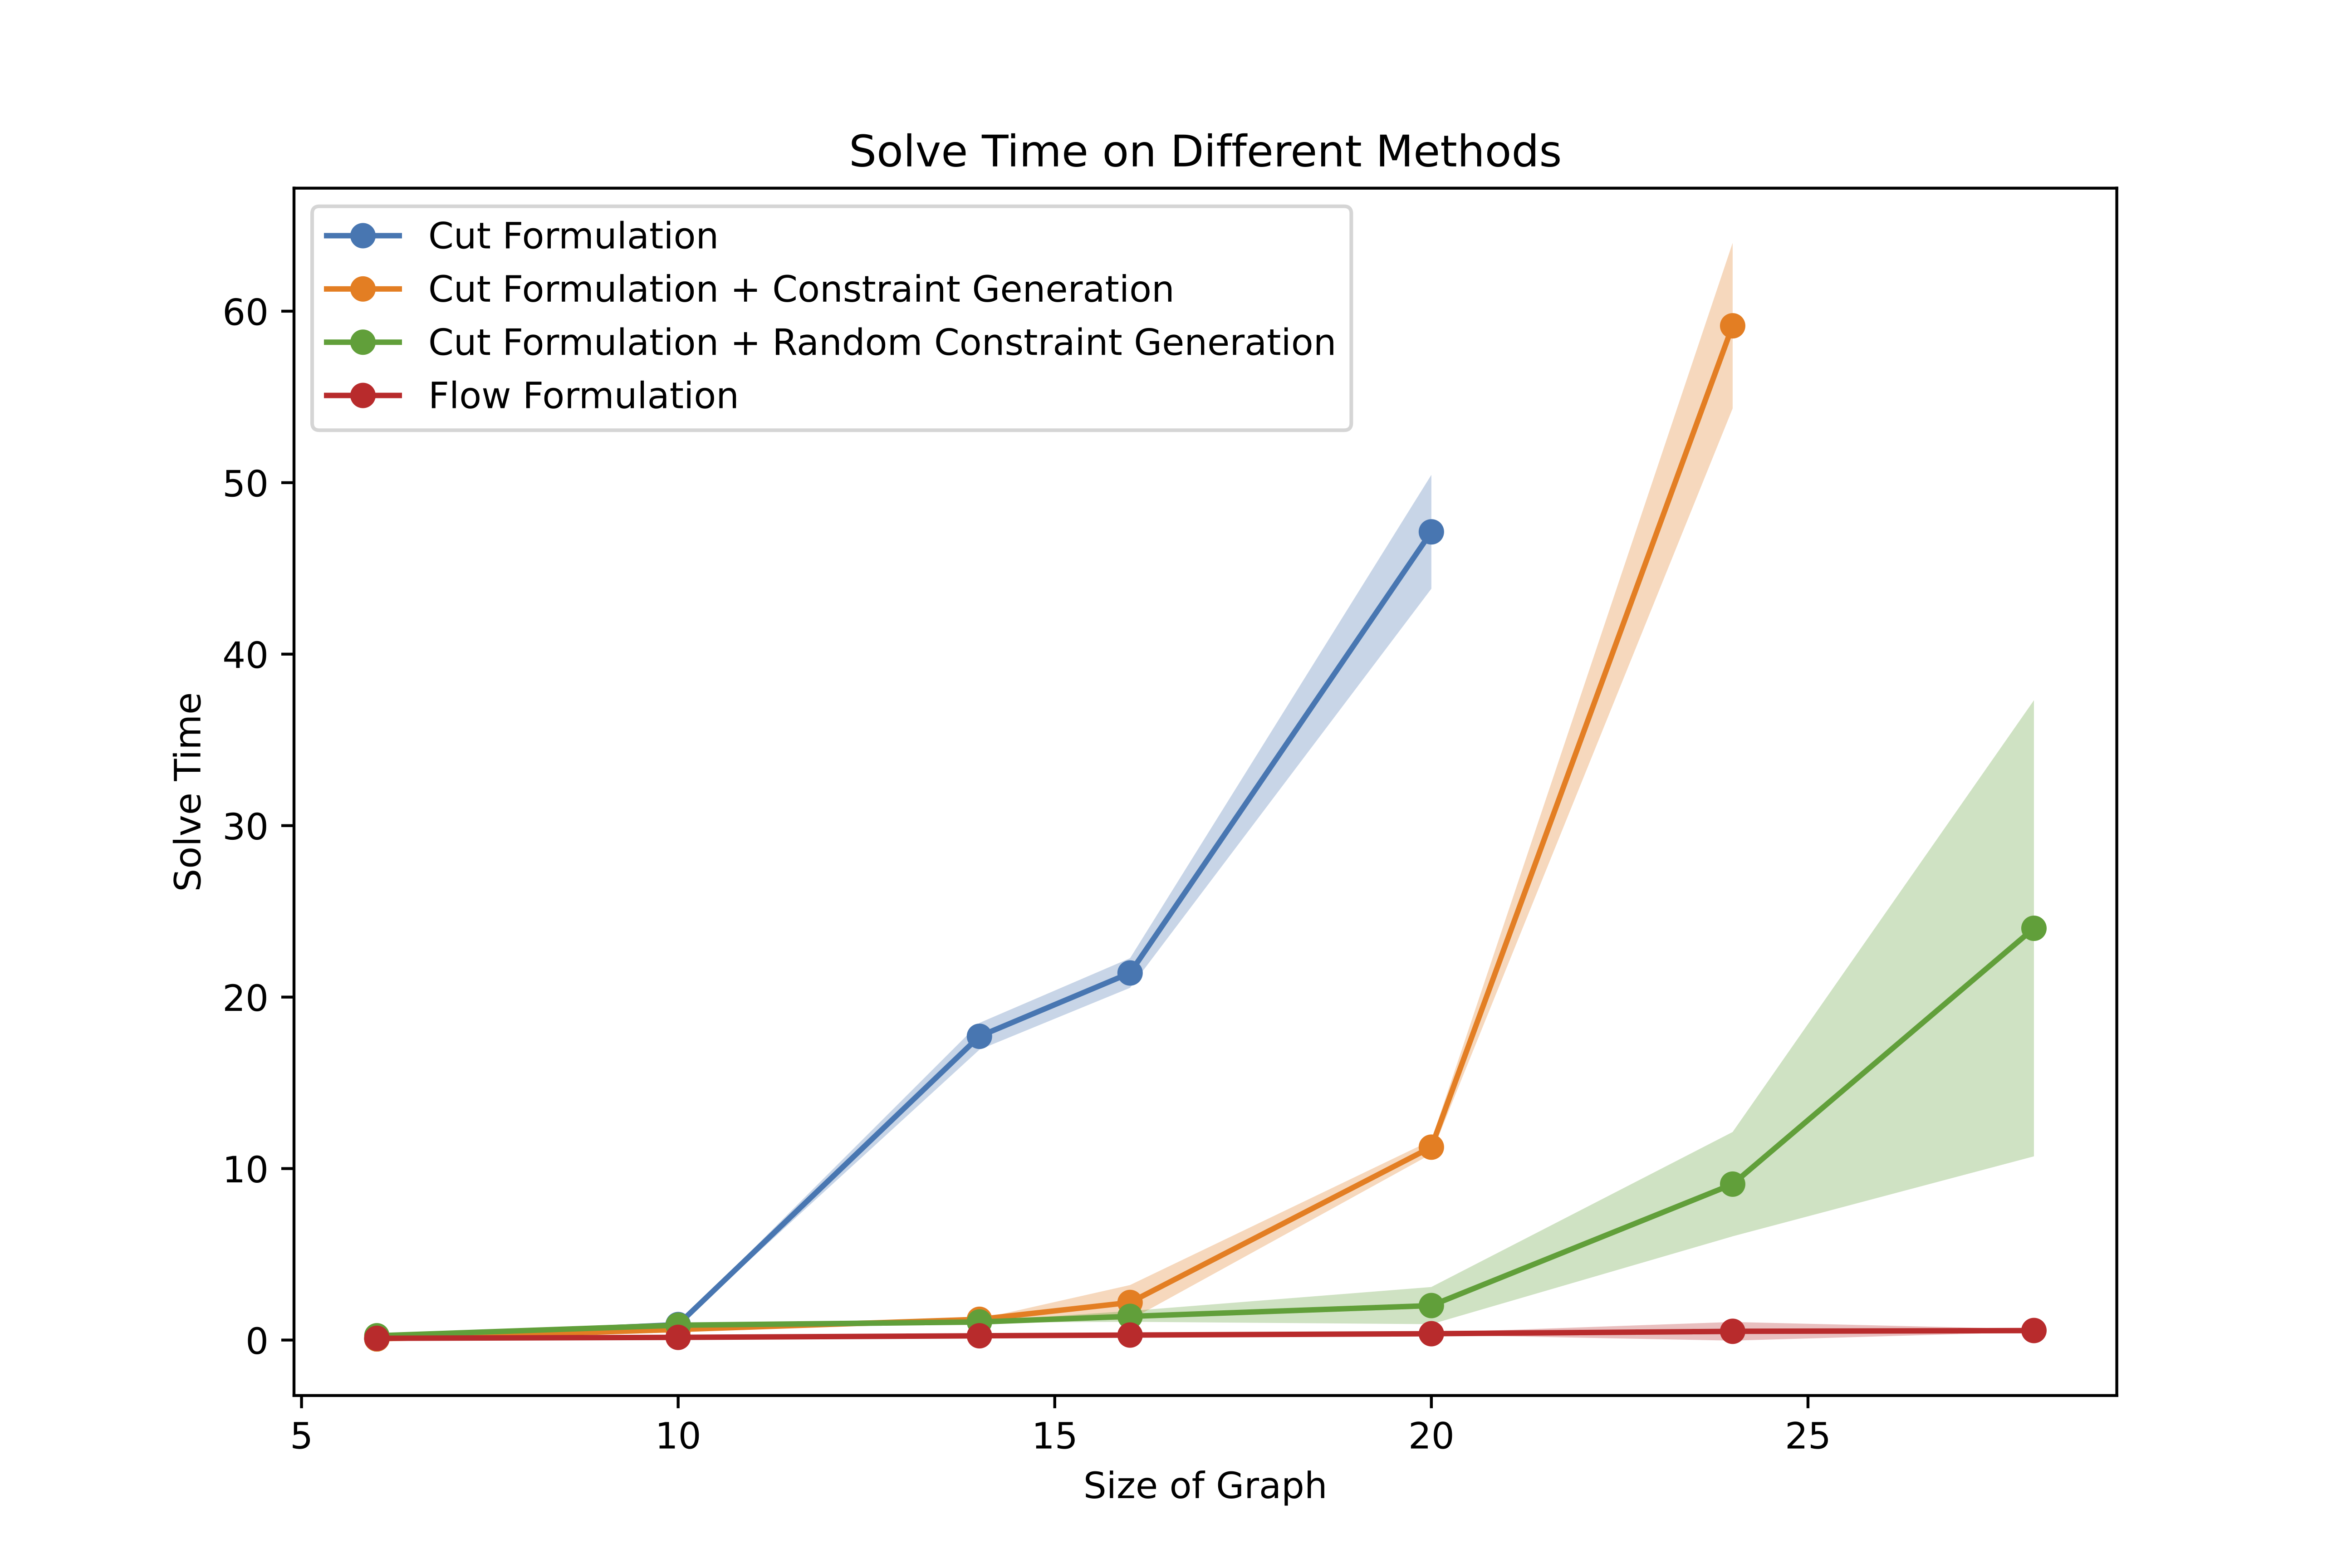

In [ ]:
from IPython.display import Image
Image('/content/sample_data/formulations.png')

This case study should give you a better idea of how two formulations can both be correct and describing the exact same problem, but one could be much better than another. Finding an efficient MIP formulation has long been a complex and well-studied task, often requiring substantial domain expertise.

In recent years, large language models (LLMs) have shown remarkable capabilities across various fields. Motivated by this, a group of researchers explored whether LLMs could be leveraged to develop a tool for automatic MIP formulation, potentially eliminating the need for deep domain expertise. Their recent work on using LLMs for optimization modeling is detailed in [this](https://arxiv.org/pdf/2402.10172) paper, which is worth checking out if you're interested!